<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 157 &middot; Communicating Results &middot; Toolkit</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Chart Recipes You Can Paste Into a Report</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">Five report-ready chart recipes, styled once and reused: a sorted bar with direct labels, a trend line that states its own takeaway, grouped before/after bars, small multiples, and an honest-versus-misleading axis. Copy any cell straight into your own analysis.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
# A clean house style for report-ready figures: no chartjunk, strong titles, muted grid.
mpl.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,
    "axes.titlelocation":"left","axes.titlepad":10})
ROSE, INK, MUT, GR, RD = "#be123c", "#1a2138", "#64748b", "#16a34a", "#dc2626"

## Recipe 1 &middot; The workhorse: a sorted bar with direct labels
For comparing categories, a horizontal bar sorted by value beats almost everything. Label the bars directly so the reader never hunts across to an axis, and let the title state the point.

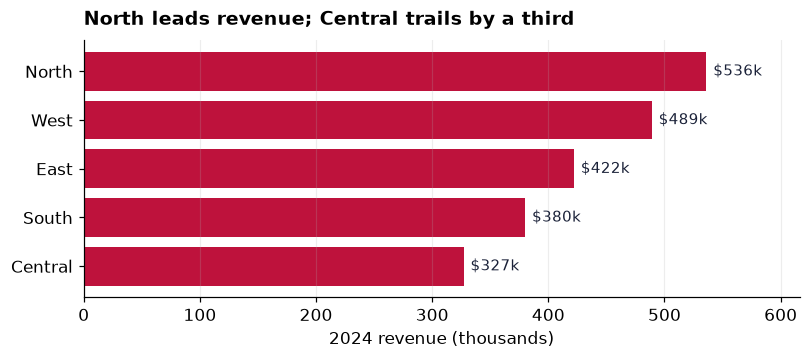

In [2]:
rev = pd.Series({"North":536,"West":489,"East":422,"South":380,"Central":327}).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(rev.index, rev.values, color=ROSE)
for y, v in enumerate(rev.values): ax.text(v+6, y, f"${v}k", va="center", fontsize=10, color=INK)
ax.set_title("North leads revenue; Central trails by a third"); ax.set_xlabel("2024 revenue (thousands)")
ax.set_xlim(0, rev.max()*1.15); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## Recipe 2 &middot; A trend line that states its own takeaway
For change over time, a single clean line. Annotate the endpoint, and put the conclusion, not the variable name, in the title. A reader who sees only the title should still get the message.

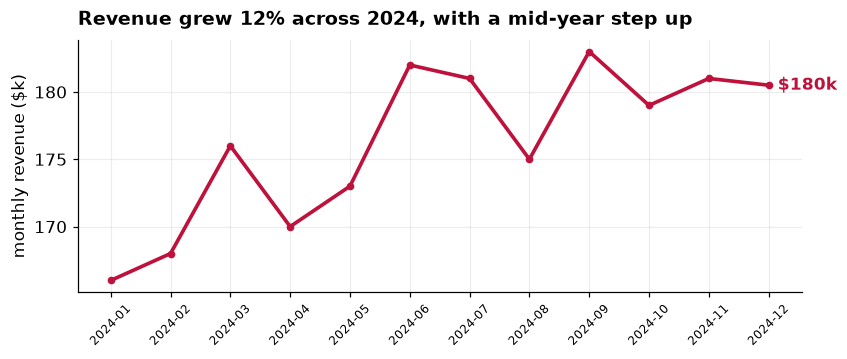

In [3]:
months = pd.period_range("2024-01","2024-12",freq="M").astype(str)
vals = np.array([166,168,176,170,173,182,181,175,183,179,181,180.5])
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(months, vals, color=ROSE, lw=2.4, marker="o", ms=4)
ax.annotate(f"${vals[-1]:.0f}k", (len(vals)-1, vals[-1]), textcoords="offset points",
            xytext=(6,0), color=ROSE, fontweight="bold", va="center")
ax.set_title("Revenue grew 12% across 2024, with a mid-year step up"); ax.set_ylabel("monthly revenue ($k)")
ax.tick_params(axis="x", rotation=45, labelsize=8); plt.tight_layout(); plt.show()

## Recipe 3 &middot; Before and after, side by side
To show a change per group, grouped bars with a legend read clearly. Keep to two series; more than that and small multiples (next) win.

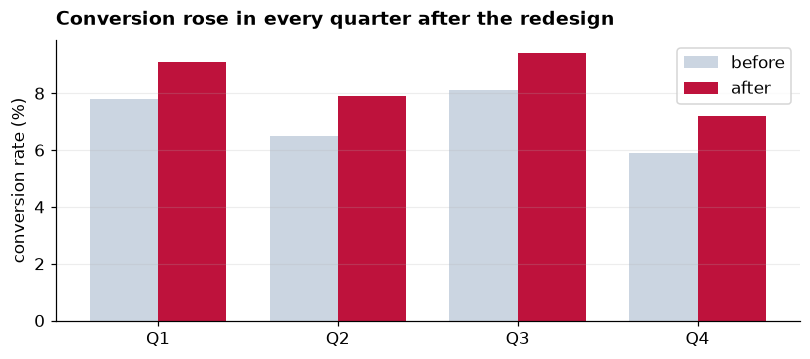

In [4]:
grp = pd.DataFrame({"before":[7.8,6.5,8.1,5.9],"after":[9.1,7.9,9.4,7.2]}, index=["Q1","Q2","Q3","Q4"])
x = np.arange(len(grp)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(x-w/2, grp["before"], w, label="before", color="#cbd5e1")
ax.bar(x+w/2, grp["after"], w, label="after", color=ROSE)
ax.set_xticks(x, grp.index); ax.set_ylabel("conversion rate (%)")
ax.set_title("Conversion rose in every quarter after the redesign"); ax.legend()
ax.grid(axis="x", visible=False); plt.tight_layout(); plt.show()

## Recipe 4 &middot; Small multiples for many groups
When one chart would tangle five lines, give each its own little panel on a shared scale. The eye compares shapes instantly, with no legend to decode.

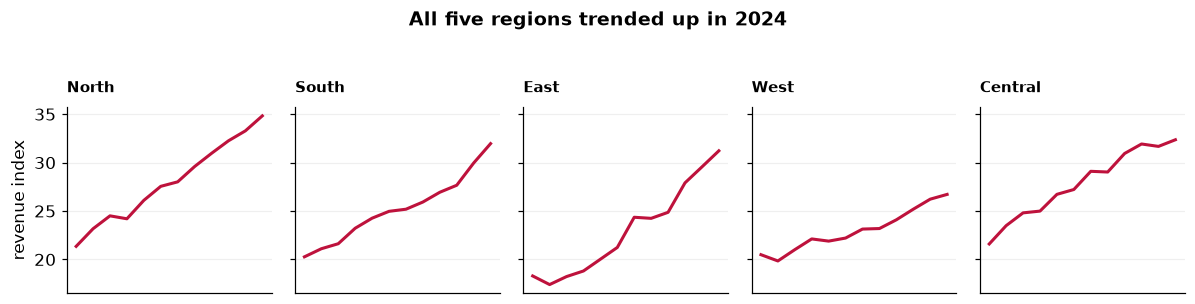

In [5]:
rng = np.random.default_rng(1)
regions = ["North","South","East","West","Central"]
fig, axes = plt.subplots(1, 5, figsize=(11, 2.6), sharey=True)
for ax, r in zip(axes, regions):
    series = np.cumsum(rng.normal(1, 1, 12)) + 20
    ax.plot(series, color=ROSE, lw=2); ax.set_title(r, fontsize=10)
    ax.set_xticks([]); ax.grid(alpha=0.2)
axes[0].set_ylabel("revenue index")
fig.suptitle("All five regions trended up in 2024", x=0.5, y=1.05, fontsize=12.5, fontweight="bold")
plt.tight_layout(); plt.show()

## Recipe 5 &middot; The honest axis (and the misleading one)
The same two numbers, drawn two ways. On the left a truncated y-axis makes a small gap look enormous; on the right a zero baseline tells the truth. For bar charts, start the axis at zero, always.

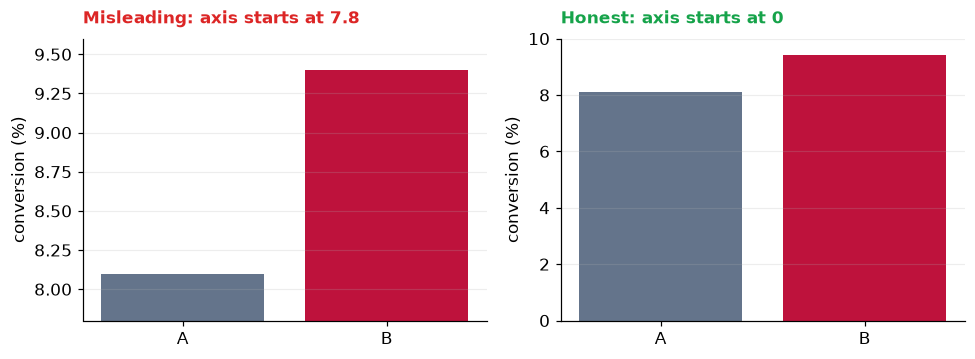

Left LOOKS like B triples A. It is a 16% lift. Same data, opposite impression.


In [6]:
a, b = 8.1, 9.4
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].bar(["A","B"], [a,b], color=[MUT,ROSE]); ax[0].set_ylim(7.8, 9.6)
ax[0].set_title("Misleading: axis starts at 7.8", color=RD, fontsize=11)
ax[1].bar(["A","B"], [a,b], color=[MUT,ROSE]); ax[1].set_ylim(0, 10)
ax[1].set_title("Honest: axis starts at 0", color=GR, fontsize=11)
for a_ in ax: a_.set_ylabel("conversion (%)"); a_.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print("Left LOOKS like B triples A. It is a 16% lift. Same data, opposite impression.")

### Wrap-up
Five patterns cover most of report work: sorted labeled bars for comparison, an annotated line for trend, grouped bars for before/after, small multiples for many groups, and always a zero baseline on bars. Style once, reuse everywhere, and let every title carry the takeaway. Next, the same idea for tables.